# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [1]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

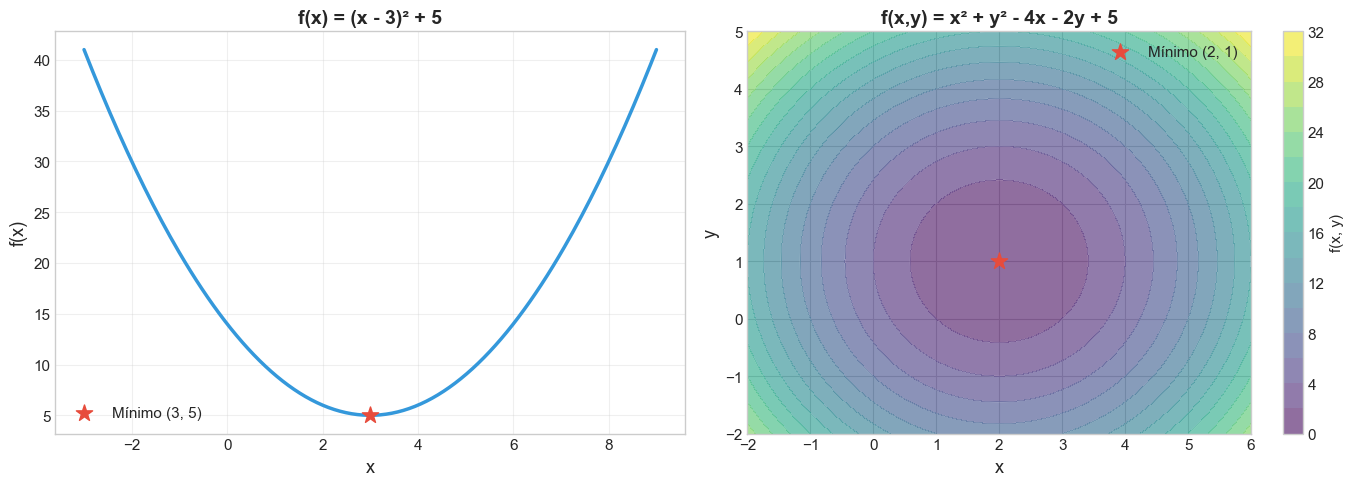

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [2]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [ ]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    

    k = 0
    x = x_inicial
    convergido = False
    
    historial_x = [x]
    historial_f = [f_1d(x)]
    datos_iteraciones = []
    
    while k <= max_iter:
        
        # a. Gradiente
        grad = df_1d(x)
        grad_norm = abs(grad)
        
        # b. Dirección de descenso
        pk = -grad
        
        alpha = learning_rate
        
        x_anterior = x
        
        # d. Guardar info tipo BGD
        datos_iteraciones.append({
            'k': k,
            'x': x,
            'p_k': pk,
            'gradiente': grad,
            'alpha': alpha,
            'f(x)': f_1d(x)
        })
        
        # e. Criterio por gradiente
        if grad_norm < tolerancia:
            convergido = True
            break
        
        # f. Actualización
        x = x + alpha * pk
        
        # g. Guardar historial
        historial_x.append(x)
        historial_f.append(f_1d(x))
        
        # h. Criterio por cambio mínimo
        cambio = abs(x - x_anterior)
        if cambio < tolerancia:
            convergido = True
            break
        
        k += 1
    
    # ============================================================
    # 3. Retorno
    # ============================================================
    return {
        'x_final': x,
        'f_final': f_1d(x),
        'iteraciones': k,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f,
        'datos_iteraciones': datos_iteraciones
    }

### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [20]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     62
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


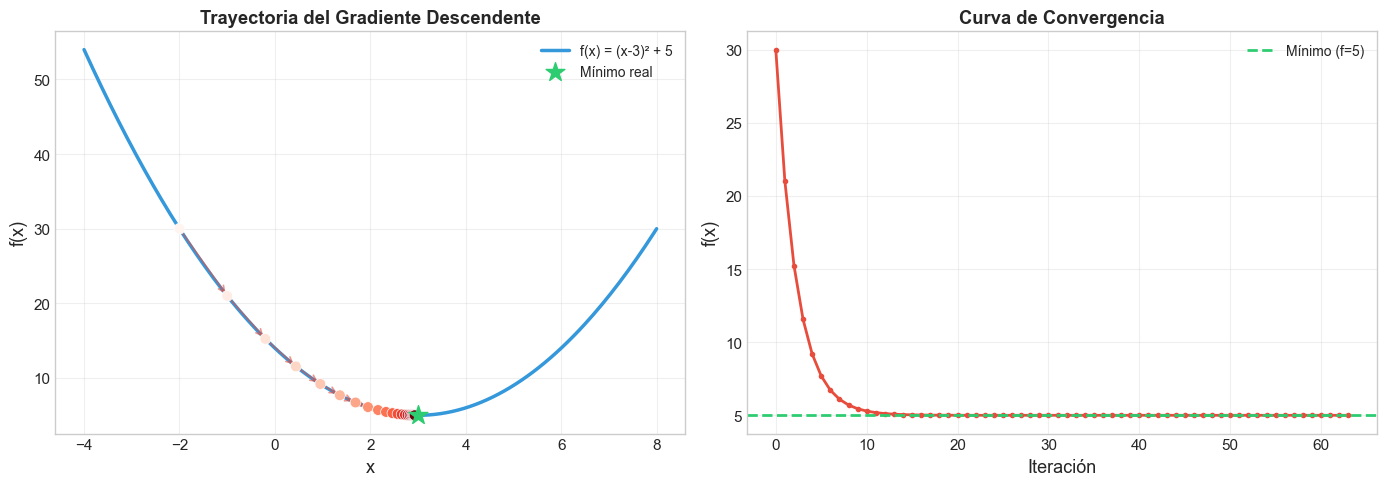

In [21]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [25]:
# ============================================================
# TU CODIGO AQUI: Ejecuta experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenar resultados
resultados_lr = []

# TU CODIGO: Para cada learning rate, ejecuta gradiente_descendente_1d
# y guarda los resultados en la lista resultados_lr
for lr in learning_rates_prueba:
    resultado = gradiente_descendente_1d(
        x_inicial=x_inicial_prueba,
        learning_rate=lr,
        max_iter=max_iter_prueba
    )
    
    resultados_lr.append(resultado)


# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergió':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
   0.001    -0.343558    16.179377          201        False
   0.010     2.913819     5.007427          201        False
   0.100     2.999996     5.000000           62         True
   0.500     3.000000     5.000000            1         True
   0.900     3.000000     5.000000           72         True
   1.000     8.000000    30.000000          201        False
   1.500 16069380442589902755419620923411626025222029937827928353013760.000000 258224987808690858965591917200301187432970579282922351283065935654064762201684119462964535328013783143590317197274749337600.000000          201        False


In [28]:
learning_rates_prueba

[0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]

### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

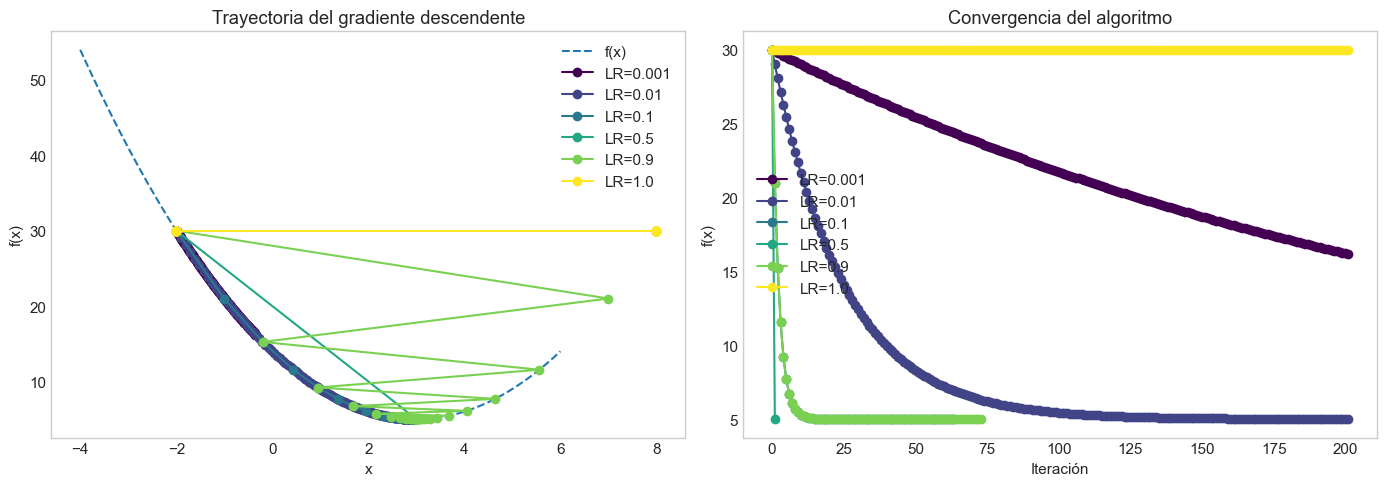

In [43]:
# ============================================================
# TU CODIGO AQUI: Grafica comparativa de learning rates
# ============================================================
# Crear figura con 2 subplots
learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colores automáticos
colores = plt.cm.viridis(np.linspace(0, 1, len(learning_rates_prueba)))

## GRÁFICA UNO

# Curva de la función real
x_vals = np.linspace(-4, 6, 200)
y_vals = [f_1d(x) for x in x_vals]
axes[0].plot(x_vals, y_vals, label="f(x)", linestyle="--")

for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores):
    xs = res['historial_x']
    ys = res['historial_f']
    
    axes[0].plot(xs, ys, marker='o', label=f"LR={lr}", color=color)

axes[0].set_title("Trayectoria del gradiente descendente")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].legend()
axes[0].grid()

# GRAFICA 2

for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores):
    ys = res['historial_f']
    axes[1].plot(range(len(ys)), ys, marker='o', label=f"LR={lr}", color=color)

axes[1].set_title("Convergencia del algoritmo")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("f(x)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

## Análisis de Learning Rate

Responde las siguientes preguntas con base en los experimentos realizados:

1. **¿Qué observas cuando utilizas un learning rate muy pequeño (por ejemplo, 0.001)?**  
   - Describe cómo afecta a la velocidad de convergencia del algoritmo.

   **Respuesta:**  
   _La velocidad para encontrar el mínimo es muy grande ya que tarda mucho más en decaer al mínimo o por la otra condición de parada puede llegar a no encontrarlo (como ocurrió en nuestro caso)_

---

2. **¿Cuál consideras que es el mejor learning rate y por qué?**  
   - Justifica tu respuesta considerando estabilidad y rapidez de convergencia.

   **Respuesta:**  
   _Un learning rate de alrededor de 0.1 es bastante estable ya que baja de manera suave y no oscila cerca del punto Lo que permite llegar al mínimo sin divegencias, siendo confiable y eficiente_

---

3. **¿Qué ocurre cuando utilizas learning rates mayores o iguales a 1.0?**  
   - Explica si el algoritmo converge, oscila o diverge.

   **Respuesta:**  
   _El algoritmo nunca converge, cuando es exactamente 1 o mayor deja de converger ya que diverge por completo del punto, es decir que al ser tan grande se salta el valor y se va a valores diferentes del mínimo_

---

4. **¿Por qué un learning rate de exactamente 1.0 presenta un comportamiento especial en esta función?**  
   - Relaciona tu respuesta con la forma de la función y su derivada.

   **Respuesta:**  
   _Debido a la derivada, al ser lineal hace que para la regla de actualización,el nuevo valor de x queda simétricamente al otro lado del mínimo. Esto provoca que el algoritmo salte de un lado al otro del punto óptimo en cada iteración, sin reducir la distancia hacia este._

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [30]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    
    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """
    x_actual, y_actual = x_inicial, y_inicial
    convergido = False
    
    historial_x = [x_actual]
    historial_y = [y_actual]
    historial_f = [f_2d(x_actual, y_actual)]
    
    # ============================================================
    # 2. Loop principal
    # ============================================================
    for k in range(max_iter):
        
        # a. Gradiente
        g = grad_2d(x_actual, y_actual)  # [gx, gy]
        grad_norm = np.linalg.norm(g)
        
        # b. Actualización
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]
        
        # c. Guardar historial
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))
        
        # d. Verificar convergencia
        if grad_norm < tolerancia:
            convergido = True
            x_actual, y_actual = x_nuevo, y_nuevo
            break
        
        # e. Actualizar
        x_actual, y_actual = x_nuevo, y_nuevo
    
    # ============================================================
    # 3. Retorno
    # ============================================================
    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': k + 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }

### Observaciones adicionales
El lr de 0.5 llega al mínimo en una sola iteración debido a la forma de la función (ser cuadrada perfecta, sin terminos diferentes). Esto hace que se llegue directamente al mínimo sin pasar por otros puntos. Sin embargo este comportamiento no es bueno para generalizar, ya que solo ocurre en funciones ideales, en casos reales no existen estas funciones y esto podria generar inestabilidad en el modelo. 

### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [31]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


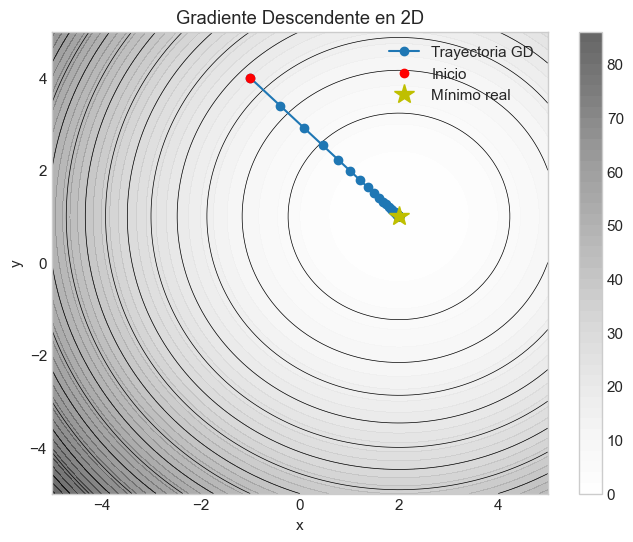

In [47]:
# ============================================================
# TU CODIGO AQUI: Visualizacion del gradiente descendente 2D
# ============================================================

# Crea una grafica con mapa de contornos que muestre:
# 1. Los contornos de la funcion f(x, y)
# 2. La trayectoria del gradiente descendente como puntos conectados
# 3. El punto de inicio marcado
# 4. El minimo real marcado con una estrella

# Pista: usa ax.contourf() para el fondo y ax.contour() para las lineas
# Pista: usa ax.plot(historial_x, historial_y, 'o-') para la trayectoria



def graficar_gradiente_descendente_2d(resultado):
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Extraer historiales
    hist_x = resultado['historial_x']
    hist_y = resultado['historial_y']
    
    # Crear malla
    x_vals = np.linspace(-5, 5, 100)
    y_vals = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = f_2d(X, Y)
    
    # Crear figura
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Contornos de fondo
    cont_fondo = ax.contourf(X, Y, Z, levels=50, alpha=0.6)
    
    # Líneas de contorno
    ax.contour(X, Y, Z, levels=20, colors='black', linewidths=0.5)
    
    # Barra de color
    plt.colorbar(cont_fondo)
    
    # Trayectoria
    ax.plot(hist_x, hist_y, 'o-', label="Trayectoria GD")
    
    # Punto inicial
    ax.plot(hist_x[0], hist_y[0], 'ro', label="Inicio")
    
    # Mínimo real
    ax.plot(2, 1, 'y*', markersize=15, label="Mínimo real")
    
    # Detalles
    ax.set_title("Gradiente Descendente en 2D")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid()
    
    plt.show()

graficar_gradiente_descendente_2d(resultado_2d)




Punto inicial: (-1.0, 4.0)
x_final: 2.000000, y_final: 1.000000
f_final: 0.000000
Iteraciones: 73
Convergió: True
----------------------------------------


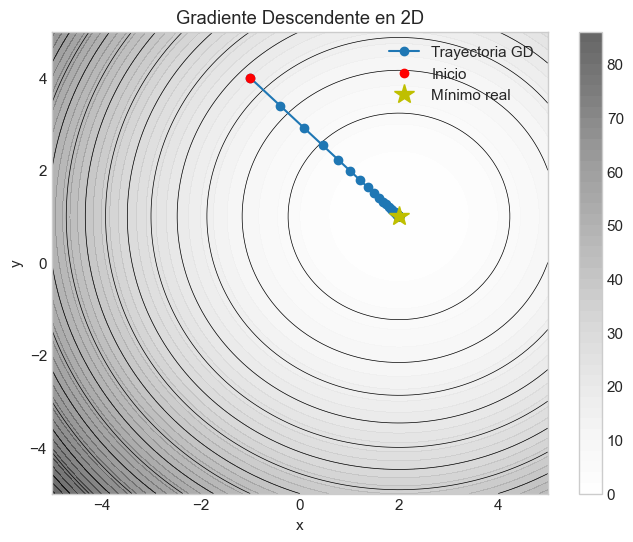

Punto inicial: (5.0, -1.0)
x_final: 2.000000, y_final: 1.000000
f_final: 0.000000
Iteraciones: 72
Convergió: True
----------------------------------------


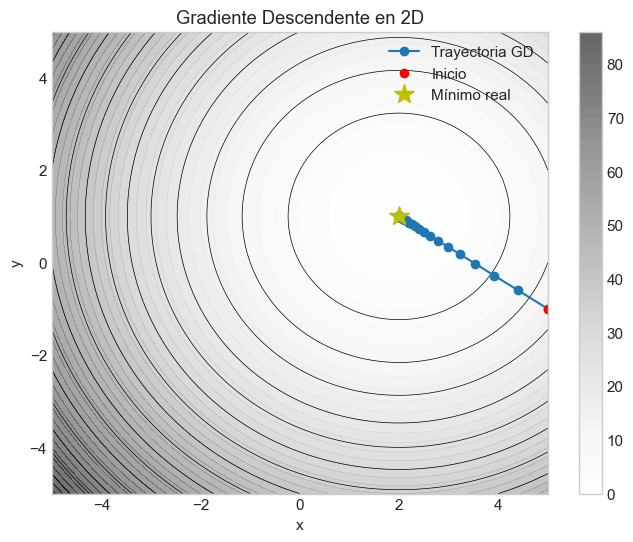

Punto inicial: (0.0, 0.0)
x_final: 2.000000, y_final: 1.000000
f_final: 0.000000
Iteraciones: 70
Convergió: True
----------------------------------------


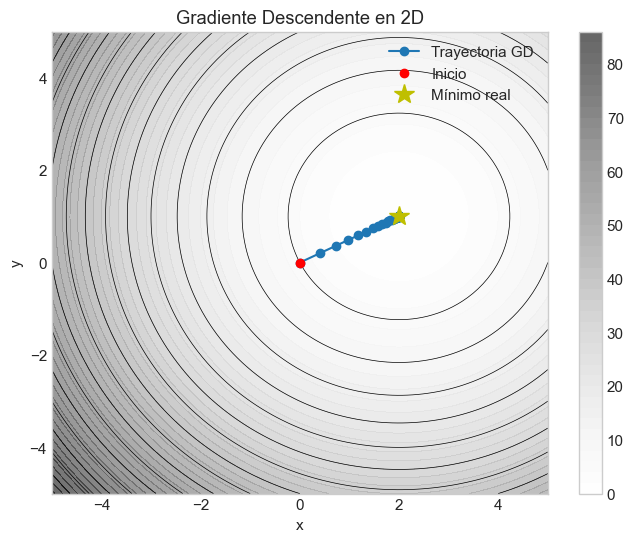

In [51]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

# Prueba al menos 3 puntos iniciales diferentes y compara los resultados
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

# TU CODIGO: ejecuta GD para cada punto inicial y muestra resultados
resultados_2d = []

# Ejecutar GD para cada punto inicial
for x0, y0 in puntos_iniciales:
    resultado = gradiente_descendente_2d(
        x_inicial=x0,
        y_inicial=y0,
        learning_rate=0.1,
        max_iter=100
    )
    
    resultados_2d.append(resultado)
    
    # Mostrar resultados
    print(f"Punto inicial: ({x0}, {y0})")
    print(f"x_final: {resultado['x_final']:.6f}, y_final: {resultado['y_final']:.6f}")
    print(f"f_final: {resultado['f_final']:.6f}")
    print(f"Iteraciones: {resultado['iteraciones']}")
    print(f"Convergió: {resultado['convergido']}")
    print("-" * 40)
    
    # Graficar trayectoria
    graficar_gradiente_descendente_2d(resultado)



---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [ ]:
# ============================================================
# TU CODIGO AQUI: Genera el DataFrame con todos los experimentos
# ============================================================

# 1. Ejecuta TODOS los experimentos:
#    - 1D: learning_rates [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
#           desde x=-2.0
#    - 2D: learning_rates [0.001, 0.01, 0.1, 0.5]
#           desde (-1, 4), (5, -1), (0, 0)

# 2. Crea el DataFrame

# 3. Guardalo como CSV

# df_experimentos = pd.DataFrame(...)
# df_experimentos.to_csv('experimentos_gd.csv', index=False)

# Lista donde guardaremos todos los experimentos
registros = []

# Experimentos 1D

learning_rates_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_1d = -2.0

for lr in learning_rates_1d:
    res = gradiente_descendente_1d(
        x_inicial=x_inicial_1d,
        learning_rate=lr,
        max_iter=200
    )
    
    registros.append({
        'learning_rate': lr,
        'dimension': '1D',
        'x_inicial': x_inicial_1d,
        'y_inicial': np.nan,
        'x_final': res['x_final'],
        'y_final': np.nan,
        'valor_minimo': res['f_final'],
        'iteraciones': res['iteraciones'],
        'convergido': res['convergido']
    })
# Experimentos 2D

learning_rates_2d = [0.001, 0.01, 0.1, 0.5]
puntos_iniciales = [(-1, 4), (5, -1), (0, 0)]

for lr in learning_rates_2d:
    for x0, y0 in puntos_iniciales:
        
        res = gradiente_descendente_2d(
            x_inicial=x0,
            y_inicial=y0,
            learning_rate=lr,
            max_iter=200
        )
        
        registros.append({
            'learning_rate': lr,
            'dimension': '2D',
            'x_inicial': x0,
            'y_inicial': y0,
            'x_final': res['x_final'],
            'y_final': res['y_final'],
            'valor_minimo': res['f_final'],
            'iteraciones': res['iteraciones'],
            'convergido': res['convergido']
        })

df_experimentos = pd.DataFrame(registros)


df_experimentos.to_csv('experimentos_gd.csv', index=False)

# Mostrar preview
print(df_experimentos.head())


   learning_rate dimension  x_inicial  y_inicial   x_final  y_final  \
0          0.001        1D       -2.0        NaN -0.343558      NaN   
1          0.010        1D       -2.0        NaN  2.913819      NaN   
2          0.100        1D       -2.0        NaN  2.999996      NaN   
3          0.500        1D       -2.0        NaN  3.000000      NaN   
4          0.900        1D       -2.0        NaN  3.000000      NaN   

   valor_minimo  iteraciones  convergido  
0     16.179377          201       False  
1      5.007427          201       False  
2      5.000000           62        True  
3      5.000000            1        True  
4      5.000000           72        True  


In [36]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial       x_final   y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.435576e-01       NaN  1.617938e+01          201       False
         0.010        1D       -2.0        NaN  2.913819e+00       NaN  5.007427e+00          201       False
         0.100        1D       -2.0        NaN  2.999996e+00       NaN  5.000000e+00           62        True
         0.500        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00            1        True
         0.900        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00           72        True
         1.000        1D       -2.0        NaN  8.000000e+00       NaN  3.000000e+01          201       False
         1.500        1D       -2.0        NaN  1.606938e+61       NaN 2.582250e+122          201       False
         0.001        2D       -1.0        4.0 -1.015484e-02  3.010155  8.081445e+00  

## Reflexión Final

1. **¿Cuál es el rango de learning rates que funciona bien para estas funciones?**  

   **Respuesta:**  
   _El rango de learning rates que funciona mejor para estas funciones se encuentra aproximadamente entre 0.01 y 0.1. En este intervalo, el algoritmo logra converger de forma estable y relativamente rápida hacia el mínimo. Valores más pequeños hacen que la convergencia sea demasiado lenta, mientras que valores mayores pueden provocar oscilaciones o divergencia (exceptuando el valor 0.5 que es un caso especial)._

---

2. **¿El punto inicial afecta si el algoritmo converge? ¿Afecta cuántas iteraciones necesita?**  

   **Respuesta:**  
   _En estas funciones, el punto inicial no afecta si el algoritmo converge, ya que son funciones convexas con un único mínimo global. Sin embargo, sí influye en el número de iteraciones necesarias: mientras más lejos esté el punto inicial del mínimo, más iteraciones se requerirán para alcanzarlo. Para funciones con mínimos locales, si puede tener problemas pues puede intentar caer en ese punto en lugar del mínimo global._

---

3. **¿Qué pasaría si la función tuviera múltiples mínimos locales? (piensa en una función como `sin(x) + x²/10`)**  

   **Respuesta:**  
   _Como se explico en la respuesta anterior, si la función tuviera múltiples mínimos locales, el algoritmo podría quedarse atrapado en uno de ellos en lugar de encontrar el mínimo global. El punto inicial jugaría un papel clave, ya que determinaría hacia qué mínimo converge el algoritmo. Esto hace que el problema sea más complejo y que la solución no siempre sea la óptima._

---

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la función de costo es como `f(x,y)`. ¿Por qué es importante elegir bien el learning rate al entrenar?**  

   **Respuesta:**  
   _Elegir un buen learning rate es esencial porque determina cómo se actualizan los pesos del modelo durante el entrenamiento. Si es muy pequeño, el entrenamiento será muy lento aumentando el costo computacional. Si es muy grande, el modelo puede no converger o volverse inestable. Un learning rate adecuado permite que el modelo aprenda de manera eficiente y estable, logrando una buena minimización de la función de costo y, por lo tanto, un mejor desempeño._

---

5. **¿Qué ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**  

   **Respuesta:**  
   _El uso del gradiente permite aprovechar información sobre la dirección en la que la función disminuye más rápidamente, lo que hace que el proceso de optimización sea mucho más eficiente. En cambio, probar valores al azar no garantiza avanzar hacia el mínimo y puede ser extremadamente lento e ineficiente. El gradiente guía el proceso de búsqueda de forma inteligente, reduciendo significativamente el número de iteraciones necesarias._

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [37]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [38]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    
    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch
    
    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """
    
    n = len(X)
    
    # 1. Inicialización
    w = 0.0
    b = 0.0
    
    historial_loss = []
    historial_w = []
    historial_b = []
    
    for epoch in range(epochs):
        
        # a. Mezclar datos
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # b. Recorrer mini-batches
        for i in range(0, n, batch_size):
            
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # c. Predicción
            y_pred = w * X_batch + b
            
            # d. Error
            error = y_batch - y_pred
            
            # e. Gradientes 
            m = len(X_batch)
            
            dw = -2/m * np.sum(error * X_batch)
            db = -2/m * np.sum(error)
            
            # f. Actualización
            w = w - learning_rate * dw
            b = b - learning_rate * db
        
        
        y_pred_total = w * X + b
        mse = np.mean((y - y_pred_total)**2)
        
        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)
    
    return {
        'w_final': w,
        'b_final': b,
        'historial_loss': historial_loss,
        'historial_w': historial_w,
        'historial_b': historial_b
    }

w final: 3.2549639029567956
b final: 6.191230748721961


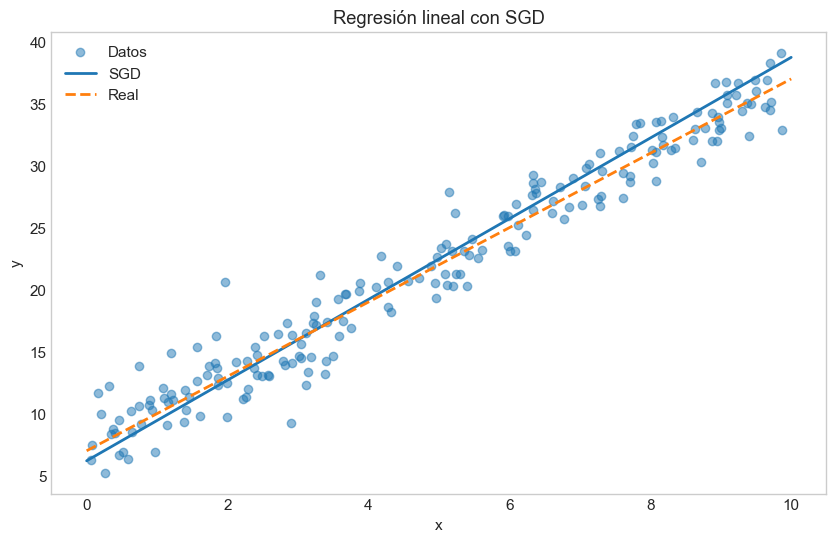

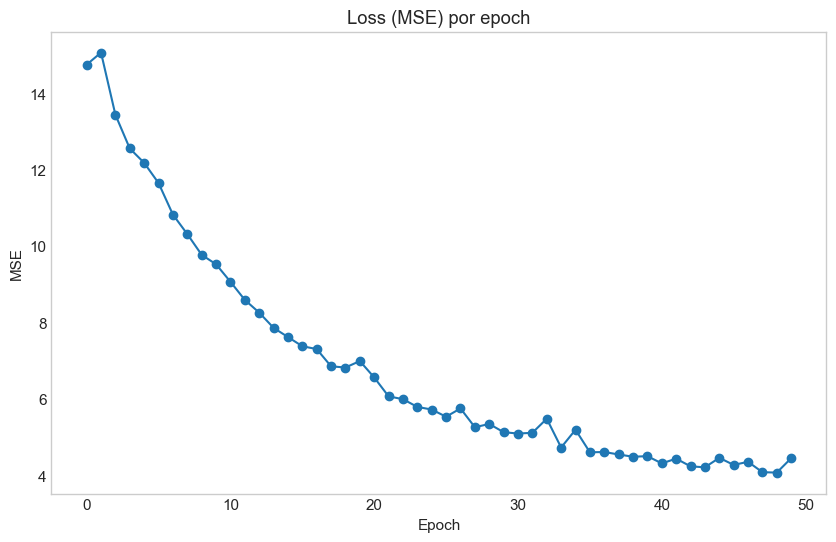

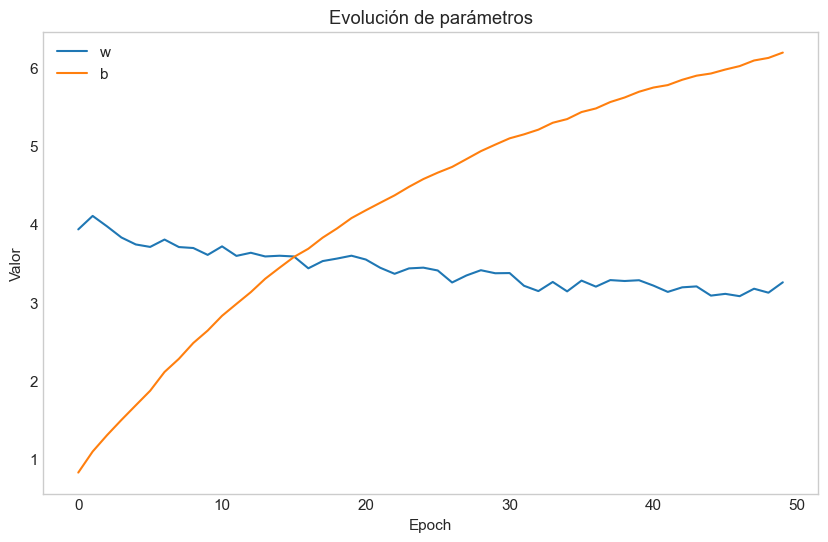

In [40]:
# Ejecuta SGD y visualiza resultados

# resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

# TU CODIGO: Crea graficas comparando:
# 1. Datos + linea aprendida por SGD vs linea real
# 2. Curva de loss por epoch
# 3. Evolucion de w y b por epoch

resultado_sgd = sgd_regresion_lineal(
    X_sgd,
    y_sgd,
    learning_rate=0.01,
    epochs=50,
    batch_size=32
)

print("w final:", resultado_sgd['w_final'])
print("b final:", resultado_sgd['b_final'])

plt.figure()

# Datos reales
plt.scatter(X_sgd, y_sgd, alpha=0.5, label="Datos")

# Línea aprendida
x_line = np.linspace(0, 10, 100)
y_pred = resultado_sgd['w_final'] * x_line + resultado_sgd['b_final']
plt.plot(x_line, y_pred, linewidth=2, label="SGD")

# Línea real
y_real = 3 * x_line + 7
plt.plot(x_line, y_real, linestyle='--', linewidth=2, label="Real")

plt.title("Regresión lineal con SGD")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.show()

plt.figure()

plt.plot(resultado_sgd['historial_loss'], marker='o')

plt.title("Loss (MSE) por epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()

plt.show()

plt.figure()

plt.plot(resultado_sgd['historial_w'], label="w")
plt.plot(resultado_sgd['historial_b'], label="b")

plt.title("Evolución de parámetros")
plt.xlabel("Epoch")
plt.ylabel("Valor")
plt.legend()
plt.grid()

plt.show()



Batch size: 1
  w_final: 2.6245
  b_final: 7.2628
----------------------------------------
Batch size: 8
  w_final: 2.9349
  b_final: 7.1843
----------------------------------------
Batch size: 32
  w_final: 3.0185
  b_final: 6.1570
----------------------------------------
Batch size: 64
  w_final: 3.2596
  b_final: 4.9153
----------------------------------------
Batch size: 200
  w_final: 3.7556
  b_final: 2.1410
----------------------------------------


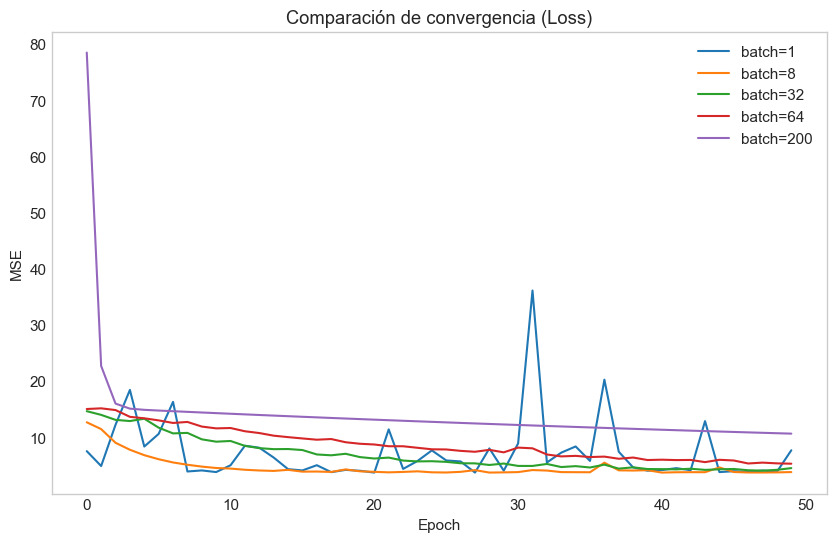

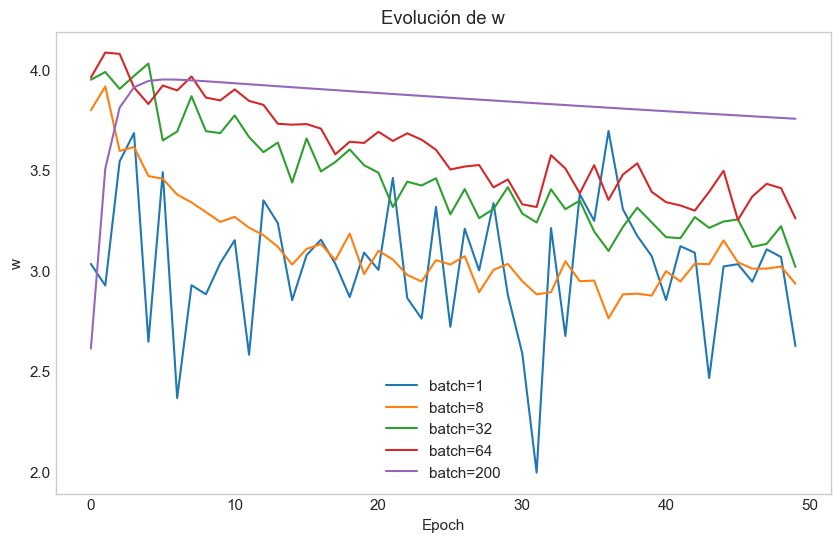

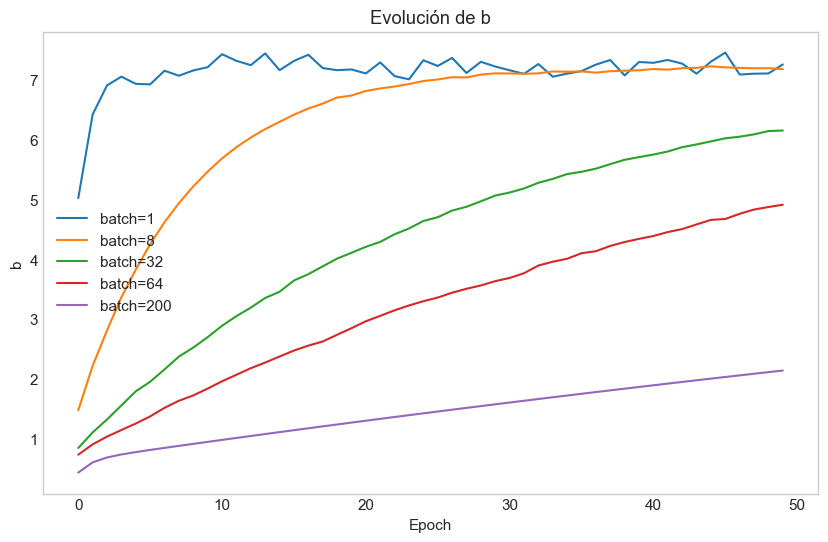

In [42]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes

# batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro

# TU CODIGO: ejecuta para cada batch_size y compara convergencia

# Batch sizes a comparar
batch_sizes = [1, 8, 32, 64, len(X_sgd)]  # len(X_sgd) = GD puro

resultados_batch = {}

# Ejecutar SGD para cada batch size
for bs in batch_sizes:
    res = sgd_regresion_lineal(
        X_sgd,
        y_sgd,
        learning_rate=0.01,
        epochs=50,
        batch_size=bs
    )
    
    resultados_batch[bs] = res
    
    print(f"Batch size: {bs}")
    print(f"  w_final: {res['w_final']:.4f}")
    print(f"  b_final: {res['b_final']:.4f}")
    print("-" * 40)


plt.figure()

for bs, res in resultados_batch.items():
    plt.plot(res['historial_loss'], label=f"batch={bs}")

plt.title("Comparación de convergencia (Loss)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid()

plt.show()

plt.figure()

for bs, res in resultados_batch.items():
    plt.plot(res['historial_w'], label=f"batch={bs}")

plt.title("Evolución de w")
plt.xlabel("Epoch")
plt.ylabel("w")
plt.legend()
plt.grid()

plt.show()


plt.figure()

for bs, res in resultados_batch.items():
    plt.plot(res['historial_b'], label=f"batch={bs}")

plt.title("Evolución de b")
plt.xlabel("Epoch")
plt.ylabel("b")
plt.legend()
plt.grid()

plt.show()


## Preguntas Bonus

1. **¿Qué diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**  

   **Respuesta:**  
   En mis resultados se observa que el SGD puro (batch_size=1) produce estimaciones más cercanas a los valores reales en comparación con GD puro (batch_size=200). Aunque SGD introduce más ruido, logra encontrar una solución más cercana al óptimo. Por otro lado, GD puro presenta una convergencia más estable, pero en este caso se aleja más de los valores reales, lo que indica que puede ser más sensible a la configuración del learning rate o quedarse en una trayectoria menos óptima.

---

2. **¿Cuál batch_size te dio los mejores resultados? ¿Por qué?**  

   **Respuesta:**  
   El batch_size que dio mejores resultados fue 32, ya que obtuvo un valor de w ≈ 3.0185, muy cercano al valor real (3). Aunque el valor de b no fue el más preciso, en general logró un buen equilibrio entre ambos parámetros. Esto sugiere que los batch sizes intermedios ofrecen un balance adecuado entre estabilidad y capacidad de ajuste, reduciendo el ruido de SGD sin perder flexibilidad en el aprendizaje.

---

3. **¿Por qué la curva de loss de SGD es más ruidosa que la de GD?**  

   **Respuesta:**  
   La curva de loss de SGD es más ruidosa porque el gradiente se calcula con muy pocas muestras en cada iteración, lo que introduce variabilidad en las actualizaciones. En contraste, GD utiliza todos los datos, por lo que el gradiente es más preciso y la convergencia es más suave. Este ruido en SGD puede parecer negativo, pero también permite explorar mejor el espacio de soluciones y evitar quedarse en soluciones subóptimas.

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_